# SVD - Concatinated Attention Heads - Activation Aware - GPT2Small

## Introduction

We will explore the activation aware `c_proj` output for the GPT2 Small model. If this model (and larger sizes) show increasing signs of parameter redundancy then it may be worth exploring a larger model size in my training.

In [1]:
%%capture
# ! pip install transformers torch==2.2.2 numpy==1.26.4 safetensors matplotlib pandas

## Define the necessary libraries

In [2]:
# Base libraries
import random

# Maths
import math
import numpy as np
import torch
import pandas as pd
from torch import nn
from tqdm.notebook import tqdm
from pathlib import Path

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Transformers
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from datasets import load_from_disk
from torch.utils.data import DataLoader

In [3]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [4]:
def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    # Ensures deterministic behavior in certain GPU operations
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_all_seeds(42)

## Load the GPT2Small Model

In [5]:
# Define the TinyGPT2 model
tokenizer = GPT2Tokenizer.from_pretrained("gpt2", local_files_only=True)
model = GPT2LMHeadModel.from_pretrained("gpt2", local_files_only=True)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

## Load the OpenWebText validation dataset

In [6]:
# Define the model path
parent = Path.cwd().parent
data_path = parent / "training_data/TinyGPT2/pretraining/Skylion007__openwebtext_ac1e385807"

In [7]:
# Load the dataset from local
dataset = load_from_disk(str(data_path))

In [8]:
# Define a dataloader
dataset.set_format(type="torch", columns=["input_ids", "attention_mask"])
loader = DataLoader(dataset["validation"], batch_size=56)

In [9]:
# Define the first batch
first_batch = next(iter(loader))
input_ids = first_batch["input_ids"]
attention_mask = first_batch["attention_mask"]

## Pass the inputs through the model

## Extract the concat attention heads

We wish to explore the activations that would be combined with the $W_o$ weights matrix, these themselves are a set of output attention heads that have been concatenated together. To do so we add a hook to each attention layer of the GPT2 model where the attention head activations are concatenated together. This captures the batches concatenated activation values, which we need to reshape to (-1, hidden_size=1024) to ensure that we can compare each of these 1024 dimensions for redundancy. We will then perform a SVD analysis on these matrices after a batch of wiki data has been passed through the model.

In [10]:
# Define the activations dictionary
activations = {}

# Define the hook fn
def get_activation(name):
    def hook(model, input, output):
        # We want the input to the dense layer (the concatenated head outputs)
        activations[name] = output.detach().cpu()
    return hook

In [11]:
# Register hooks for all layers' output projections
for i in range(model.config.num_hidden_layers):
    _ = model.transformer.h[i].attn.c_proj.register_forward_hook(get_activation(f'layer_{i}'))

In [12]:
# Pass data through the model
with torch.no_grad():
    first_batch = {k: v.to("cpu") for k, v in first_batch.items()}
    output = model(**first_batch)

## Examine the activations

In [13]:
# Examine the number of activations captured
len(activations)
activations["layer_0"].shape

12

torch.Size([56, 512, 768])

In [14]:
# Define the hidden size
hidden_size = activations["layer_0"].shape[-1]

In [15]:
# Extract the concated head data
activations_list = list(activations.values())

In [16]:
# Reshape the activation data
activations_list = [item.reshape(-1, hidden_size) for item in activations_list]
activations_list[0].shape

torch.Size([28672, 768])

In [17]:
# Save the filtered activations
flattened_activations_list = []

# Filter padding from hooks
for activations in tqdm(activations_list, total=len(activations_list)):
    act_np = np.array(activations)
    mask_np = np.array(attention_mask).flatten()
    
    # Use NumPy's boolean indexing to keep only non-padding tokens (where mask == 1)
    filtered_act = act_np[mask_np > 0]
    
    # Convert back to MLX for the SVD
    flattened_activations_list.append(filtered_act)

  0%|          | 0/12 [00:00<?, ?it/s]

/var/folders/qk/0rxgwz9j1yxdvlb5qw_rylk40000gn/T/ipykernel_15532/2181563792.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  act_np = np.array(activations)
/var/folders/qk/0rxgwz9j1yxdvlb5qw_rylk40000gn/T/ipykernel_15532/2181563792.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  mask_np = np.array(attention_mask).flatten()


In [18]:
# Examine the shape of the filtered data
flattened_activations_list[0].shape

(28672, 768)

## Apply SVD to each layer

## Calculate the effective rank of each activation matrix

### Retension based rank (Energy Cutoff)

This is a threshold based matric, which focuses on the question, how many singular values do I need to preserve at least $x\%$ of the matrices total energy. This allows for the direct calculation of compressibility of a matrix.

In particular, in ML the singular value represents the stretch of each dimension, but S squared represents the energy (or variance) contained in that dimension.

In [19]:
def calculate_retension_based_rank(S, threshold_list):
    """
    This function take a matrices singular values and estimate the retension based rank for a list of thresholds.
    It essentially takes the singular values, squares them to represent each Wo dimensions variance and subsequently, calculates 
    the cumulative percentage energy values. Then taking the thresholds we find the number of dimensions that combine to cross the 
    pre-defined minimum thresholds.
    """

    # Calculate the cumulative percentage energy values -> Cumulative sum / total energy (S**2)
    cumulative_energy = np.cumsum(S**2) / np.sum(S**2)

    # Find smallest k such that cumulative energy >= alpha
    retention_based_rank_values = [{threshold: np.searchsorted(cumulative_energy, threshold) + 1} for threshold in threshold_list]

    return retention_based_rank_values

### Entropy based effective rank

Given singular values $S$ of a matrix $W$, we want to calculate the effective rank, such that:

- If the spectrum is uniform → rank is high
- If a few singular values dominate → rank is low
- If one singular value dominates → rank ≈ 1
- If all singular values are equal → rank = full rank

The entropy-based effective rank satisfies all of these.

In [20]:
def calculate_effective_rank(S):
    """
    Calculating the entropy based effective rank value. Remember that S**2 represents the energy of that dimension and thus we initially 
    calculate a energy based probability distribution which sums to 1. We then measure the uncertainty via the entropy calculation. We then
    convert back to a rank value by taking the exp.
    """

    # Calculate the energy based probability
    p = (S**2) / np.sum(S**2)

    # Calculate the Shannon entropy (log scale)
    H = -np.sum(p * np.log(p))
    
    # Calculate the effective rank (R scale)
    entropy_based_effective_rank = np.exp(H)

    return entropy_based_effective_rank

In [21]:
def calculate_SVD_rank_metrics(H):
    """
    First calculate the SVD and then calculate the retension based rank value and entropy baesd effective rank values. 
    """

    # Create a list to store the results
    svd_layers = []
    
    # For each layers WO matrix
    for layer, h in tqdm(enumerate(H), total=len(H)):

        # Center each of the 312 dimensions across all tokens (variance about the mean,
        # not energy about the origin — removes the anisotropy/mean-offset direction)
        h = h - h.mean(axis=0, keepdims=True)
    
        # Calculate the SVD
        U, S, VT = np.linalg.svd(h, full_matrices=False)
    
        # Calculate the retension based rank values
        retension_based_rank_values = calculate_retension_based_rank(S, [0.99, 0.999])    
    
        # Calculate the entropy based effective rank
        entropy_based_effective_rank = calculate_effective_rank(S)
        
        # Store the results
        svd_layers.append({
            "layer": layer,
            "U": U,
            "S": S,
            "VT": VT,
            "retension_based_rank_values": retension_based_rank_values,
            "entropy_based_effective_rank": entropy_based_effective_rank,
        })

    return svd_layers

In [22]:
# Calculate the entropy based effective rank and also retention based rank values
svd_layers = calculate_SVD_rank_metrics(flattened_activations_list)

  0%|          | 0/12 [00:00<?, ?it/s]

In [23]:
# Convert to a dataframe
svd_layers_df = pd.DataFrame(svd_layers)

In [24]:
# Expand out the retensio based rank values
svd_layers_df_expanded = pd.concat([
    svd_layers_df.drop(columns='retension_based_rank_values'),
    svd_layers_df['retension_based_rank_values'].apply(lambda lst: {k: v for d in lst for k, v in d.items()}).apply(pd.Series)
], axis=1)

In [25]:
# Rename the columns
svd_layers_df_expanded = svd_layers_df_expanded.rename(columns={0.99: 'r99', 0.999: 'r99.9'})


## Plot the curves of the retension based rank values

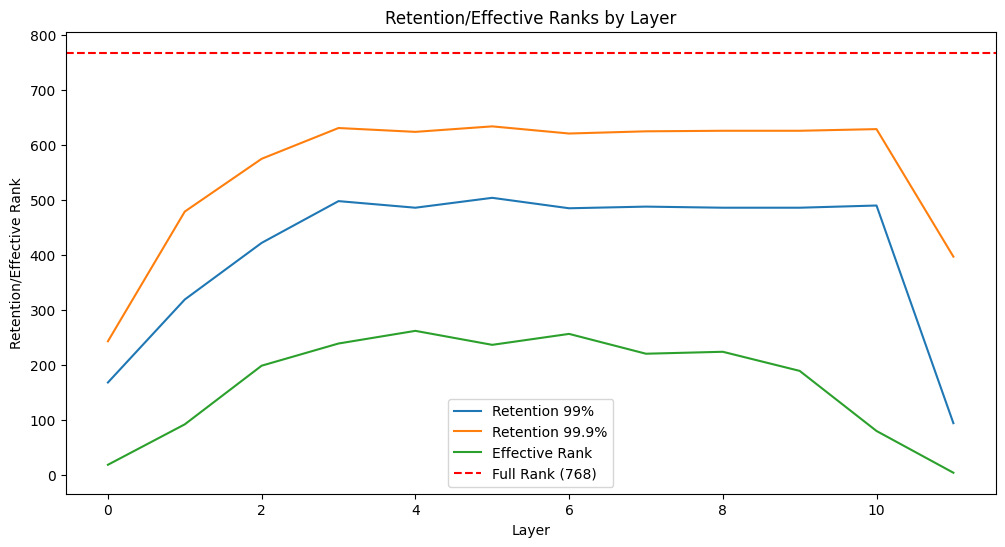

In [26]:
# Plot the  
ax = svd_layers_df_expanded.plot(x='layer', y=['r99', 'r99.9', 'entropy_based_effective_rank'], figsize=(12, 6))

# Add a custom horizontal line
_ = plt.axhline(y=hidden_size, color='red', linestyle='--', label='Threshold Line')

# Add titles, labels and legend
_ = plt.ylabel('Retention/Effective Rank')
_ = plt.xlabel('Layer')
_ = plt.title('Retention/Effective Ranks by Layer')
_ = ax.legend(['Retention 99%', 'Retention 99.9%', "Effective Rank", f"Full Rank ({hidden_size})"])
plt.show()

## Calculate the average value across the different layers

In [27]:
# Calculate the average retension/effective rank across the layers
print("r99: ", f"{svd_layers_df_expanded['r99'].mean():.2f}")
print("r99.9: ", f"{svd_layers_df_expanded['r99.9'].mean():.2f}")
print("entropy_based_effective_rank: ", f"{svd_layers_df_expanded['entropy_based_effective_rank'].mean():.2f}")

r99:  410.50
r99.9:  559.17
entropy_based_effective_rank:  168.29


## Conclusion

The effective rank varies across the layers. Starting low and then increasing over time. I would still suggest from this plot that there is redundancy in the model.